# Multi-dataset sentiment EDA (`sentiment-analysis/`)

**Location:** `data/datasets/sentiment-analysis/`

**Goal:** Compare train/test vs Sentiment140-style files, check for **neutral** labels (numeric `2` or string `neutral`), text quality, and produce a shareable summary CSV.

**Constraints:** pandas + matplotlib only (via `eda_helpers.read_csv_safe` for encoding). Default matplotlib colors, one figure per plot.

**Outputs:** `data/processed/sentiment_dataset_eda_summary.csv`

**Note:** `training.1600000.processed.noemoticon.csv` is ~1.6M rows — expect noticeable RAM and runtime on a full pass.


In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_HERE = Path.cwd().resolve()
if (_HERE / "data" / "datasets").is_dir():
    PROJECT_ROOT = _HERE
elif (_HERE.parent / "data" / "datasets").is_dir():
    PROJECT_ROOT = _HERE.parent
else:
    raise FileNotFoundError("Run from repo root or notebooks/")

sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import eda_helpers as edh

DATA_DIR = PROJECT_ROOT / "data" / "datasets" / "sentiment-analysis"
OUT_CSV = PROJECT_ROOT / "data" / "processed" / "sentiment_dataset_eda_summary.csv"
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

NO_HEADER_COLS = ["polarity", "id", "date", "query", "user", "text"]

DATASET_FILES = [
    "train.csv",
    "test.csv",
    "testdata.manual.2009.06.14.csv",
    "training.1600000.processed.noemoticon.csv",
]


def read_csv_safe(path: Path, **kwargs):
    return edh.read_csv_safe(path, **kwargs)


def load_dataset(path: Path) -> pd.DataFrame:
    # utf-8 then latin-1 via eda_helpers; per-file header rules below.
    name = path.name
    if name == "testdata.manual.2009.06.14.csv":
        return read_csv_safe(
            path, header=None, names=NO_HEADER_COLS, on_bad_lines="skip"
        )
    if name == "training.1600000.processed.noemoticon.csv":
        # First line is a prose header, not data
        return read_csv_safe(
            path,
            header=None,
            names=NO_HEADER_COLS,
            skiprows=1,
            on_bad_lines="skip",
        )
    if name in ("train.csv", "test.csv"):
        return read_csv_safe(path, on_bad_lines="skip")
    raise ValueError(f"Unknown dataset file: {name}")


def detect_text_label_columns(df: pd.DataFrame) -> tuple[str, str]:
    label_col = None
    for c in ("sentiment", "polarity", "label"):
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        for c in df.columns:
            nu = df[c].nunique(dropna=False)
            if nu <= 25 and str(c).lower() not in ("text", "textid", "id"):
                label_col = c
                break
    if label_col is None:
        raise ValueError("Could not detect label column")

    if "text" in df.columns:
        text_col = "text"
    else:
        text_col = None
        for c in df.columns:
            cl = str(c).lower()
            if "text" in cl and "id" not in cl:
                text_col = c
                break
    if text_col is None:
        raise ValueError("Could not detect text column")
    return text_col, label_col


def neutral_present(labels: pd.Series) -> tuple[bool, str]:
    u = labels.dropna()
    if len(u) == 0:
        return False, "no labels"
    if pd.api.types.is_numeric_dtype(u):
        num = pd.to_numeric(u, errors="coerce")
        if (num == 2).fillna(False).any():
            return True, "numeric polarity 2 (Sentiment140 neutral)"
        uniq = sorted(pd.unique(num.dropna()), key=float)
        return False, f"numeric labels only (sample): {uniq[:12]}"
    low = u.astype(str).str.lower().str.strip()
    if low.eq("neutral").any():
        return True, "string label 'neutral' present"
    return False, f"string labels (sample): {list(low.unique())[:12]}"


def balance_assessment(vc: pd.Series) -> tuple[str, str]:
    n = int(vc.sum())
    if n == 0:
        return "NO", "no rows"
    p = vc.astype(float) / n
    mn, mx = float(p.min()), float(p.max())
    ok = mn >= 0.05 and mx <= 0.80
    return ("YES" if ok else "NO"), f"min class share {mn:.1%}, max {mx:.1%}"


def three_class_usable(has_neutral: bool, labels: pd.Series) -> tuple[str, str]:
    if not has_neutral:
        return "NO", "no neutral class detected"
    u = labels.dropna()
    if pd.api.types.is_numeric_dtype(u):
        n_neu = int((u == 2).sum() + (u == 2.0).sum())
    else:
        low = u.astype(str).str.lower().str.strip()
        n_neu = int(low.eq("neutral").sum())
    n_classes = int(labels.nunique(dropna=True))
    if n_neu < 100:
        return "NO", f"neutral count too small ({n_neu})"
    if n_classes < 3:
        return "NO", f"only {n_classes} distinct labels"
    return "YES", f"neutral rows ~{n_neu}; {n_classes} classes"


def labels_pretty(labels: pd.Series) -> str:
    return ", ".join(str(x) for x in labels.value_counts().sort_index().index.tolist())


def recommend_usage(row: dict) -> str:
    name = row["dataset"]
    n = row["rows"]
    neu = row["neutral_present"]
    bal = row["balanced"]
    dup = row["duplicates_pct"]
    n_lab = row["n_labels"]

    parts = []
    if dup > 45:
        return "not recommended (extreme duplicate text)"
    if neu == "Y":
        parts.append("neutral source")
    if n >= 400_000:
        parts.append("pretraining")
    if name in ("train.csv", "test.csv") and neu == "Y":
        parts.append("fine-tuning")
    if "testdata.manual" in name:
        parts.append("fine-tuning / held-out eval")
    if n < 50_000 and n_lab >= 3 and neu == "Y":
        parts.append("fine-tuning / eval")
    if not parts:
        parts.append("binary supervision / pretraining auxiliary")
    # de-dupe preserve order
    out = []
    for p in parts:
        if p not in out:
            out.append(p)
    return "; ".join(out)


# Re-run this entire setup cell to reset the list before a full pass.
summary_rows = []


## EDA function (sections A–G)

Run the next cell once to define `run_full_eda`. Then run each **dataset** cell below (they append to `summary_rows`; re-run the setup cell above to clear it).

In [10]:
def run_full_eda(dataset_name: str, path: Path) -> dict:
    sep = "=" * 72
    print(f"\n{sep}\n## Dataset: {dataset_name}\n{sep}")

    # --- A. Load ---
    print("\n### A. Load dataset")
    df = load_dataset(path)
    print("Path:", path.resolve())
    print("Rows loaded:", len(df))

    # --- B. Basic info ---
    print("\n### B. Basic info")
    print("shape:", df.shape)
    print("column names:", list(df.columns))
    print("\nhead(5):")
    print(df.head(5).to_string())
    print("\nnull counts per column:")
    print(df.isnull().sum().to_string())
    dup_rows = int(df.duplicated().sum())
    print(f"\nduplicate rows (full row): {dup_rows}")

    text_col, label_col = detect_text_label_columns(df)
    labels = df[label_col]

    # --- C. Label analysis ---
    print("\n### C. Label analysis")
    print("Using label column:", label_col)
    uniq = labels.dropna().unique()
    print("unique label values:", np.array(sorted(uniq, key=str)))
    vc = labels.value_counts().sort_values(ascending=False)
    print("\nvalue_counts (sorted by count desc):")
    print(vc.to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    vc.plot(kind="bar", ax=ax, rot=45)
    ax.set_title(f"Label distribution — {dataset_name}")
    ax.set_xlabel("label")
    ax.set_ylabel("count")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

    has_neutral, neutral_note = neutral_present(labels)
    print("\nDoes this dataset contain neutral?", "YES" if has_neutral else "NO")
    print("  →", neutral_note)
    print("What labels exist?", list(np.array(sorted(uniq, key=str))))

    # --- D. Text analysis ---
    print("\n### D. Text analysis")
    print("Using text column:", text_col)
    s = df[text_col].fillna("").astype(str)
    char_len = s.str.len()
    word_len = s.str.split().str.len().clip(lower=0)

    print("Average word length:", float(word_len.mean()))
    print("Median word length:", float(word_len.median()))
    print("Average char length:", float(char_len.mean()))
    print("Median char length:", float(char_len.median()))
    print("Min / max words:", int(word_len.min()), int(word_len.max()))
    print("Min / max chars:", int(char_len.min()), int(char_len.max()))

    print("\n5 shortest texts (by word count):")
    short_idx = word_len.nsmallest(5).index
    for i, idx in enumerate(short_idx, 1):
        t = df.at[idx, text_col]
        print(f"  {i}. ({int(word_len.loc[idx])} words)", repr(t)[:200])

    print("\n5 longest texts (by word count):")
    long_idx = word_len.nlargest(5).index
    for i, idx in enumerate(long_idx, 1):
        t = df.at[idx, text_col]
        print(f"  {i}. ({int(word_len.loc[idx])} words)", repr(t)[:200])

    url_pct = 100.0 * s.str.contains("http", case=False, na=False).mean()
    mention_pct = 100.0 * s.str.contains("@", regex=False, na=False).mean()
    hash_pct = 100.0 * s.str.contains("#", regex=False, na=False).mean()
    print(f"\n% rows with URL (http): {url_pct:.2f}")
    print(f"% rows with @ mention: {mention_pct:.2f}")
    print(f"% rows with # hashtag: {hash_pct:.2f}")

    # --- E. Data quality ---
    print("\n### E. Data quality checks")
    empty_pct = 100.0 * (s.str.strip().str.len() == 0).mean()
    near_empty_pct = 100.0 * (s.str.strip().str.len() <= 1).mean()
    dup_text_pct = 100.0 * df[text_col].duplicated().mean()
    non_str_mask = ~df[text_col].map(lambda x: isinstance(x, str))
    n_non_str = int(non_str_mask.sum())
    p99 = float(char_len.quantile(0.99))
    thresh = max(p99 * 3, 8000)
    n_long_out = int((char_len > thresh).sum())

    print(f"% empty text: {empty_pct:.2f}")
    print(f"% near-empty text (<=1 char after strip): {near_empty_pct:.2f}")
    print(f"% duplicate text (same text column): {dup_text_pct:.2f}")
    print(f"non-string text cells: {n_non_str}")
    print(
        f"extreme long texts (chars > max(99th pct*3, 8000), 99th={p99:.0f}): {n_long_out}"
    )

    # --- F. Schema detection ---
    print("\n### F. Schema detection")
    print("Detected text column:", text_col)
    print("Detected label column:", label_col)
    df_standard = df[[text_col, label_col]].rename(
        columns={text_col: "text", label_col: "label"}
    )
    print("\nStandardized preview df_standard = df[[text, label]] renamed:")
    print(df_standard.head(5).to_string())

    # --- G. Neutral usability ---
    print("\n### G. Neutral usability check")
    bal_yn, bal_expl = balance_assessment(vc)
    tc_yn, tc_expl = three_class_usable(has_neutral, labels)
    print("Neutral present? →", "YES" if has_neutral else "NO")
    print("  ", neutral_note)
    print("Label distribution balanced? →", bal_yn)
    print("  ", bal_expl)
    print("Usable for 3-class training? →", tc_yn)
    print("  ", tc_expl)

    n = len(df)
    return {
        "dataset": dataset_name,
        "rows": n,
        "labels_present": labels_pretty(labels),
        "n_labels": int(labels.nunique(dropna=True)),
        "neutral_present": "Y" if has_neutral else "N",
        "balanced": bal_yn,
        "three_class": tc_yn,
        "avg_text_words": float(word_len.mean()),
        "avg_text_chars": float(char_len.mean()),
        "duplicates_pct": round(dup_text_pct, 2),
        "neutral_note": neutral_note,
        "balanced_note": bal_expl,
        "three_class_note": tc_expl,
    }


### Dataset: `train.csv`

Sections A–G for this file.


## Dataset: train.csv

### A. Load dataset
Path: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis/data/datasets/sentiment-analysis/train.csv
Rows loaded: 27481

### B. Basic info
shape: (27481, 10)
column names: ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

head(5):
       textID                                                                         text                        selected_text sentiment Time of Tweet Age of User      Country  Population -2020  Land Area (Km²)  Density (P/Km²)
0  cb774db0d1                                          I`d have responded, if I were going  I`d have responded, if I were going   neutral       morning        0-20  Afghanistan          38928346         652860.0               60
1  549e992a42                                Sooo SAD I will miss you here in San Diego!!!                             Sooo SAD  negative          no

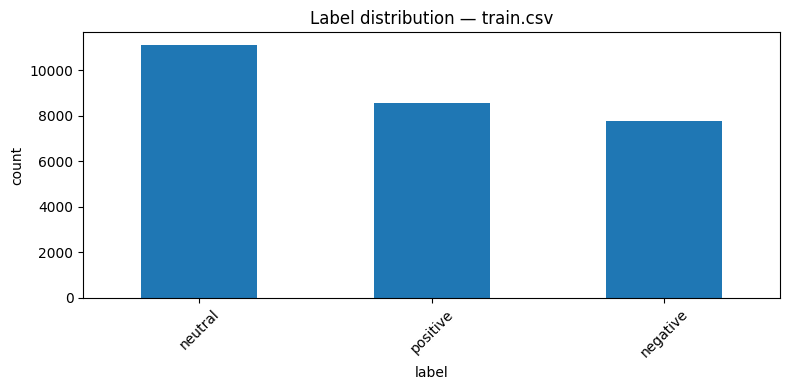


Does this dataset contain neutral? YES
  → string label 'neutral' present
What labels exist? [np.str_('negative'), np.str_('neutral'), np.str_('positive')]

### D. Text analysis
Using text column: text
Average word length: 12.902405298206034
Median word length: 12.0
Average char length: 68.35246170081147
Median char length: 64.0
Min / max words: 0 33
Min / max chars: 0 159

5 shortest texts (by word count):
  1. (0 words) nan
  2. (1 words) 'MAYDAY?!'
  3. (1 words) 'Chilliin'
  4. (1 words) ' Absolutely'
  5. (1 words) '_nesmith'

5 longest texts (by word count):
  1. (33 words) 'AK, flop comes 2K6 I bet 15 get raised to 25 I call, turn is A, we check, river rag, then I check and he bets 15, I raise 15 he calls, 22'
  2. (33 words) ': Lol it went okay! As far as I can tell . But then I had to do a test today for geo and I was all zoned out and got like 65%'
  3. (32 words) 'How I wish I get at least 2 days-off in a row. 1 day off is not enough to rest.  3 days on, 1 day off, 4 days o

In [4]:
p = DATA_DIR / "train.csv"
if not p.exists():
    raise FileNotFoundError(f"Missing {p} — expected under data/datasets/sentiment-analysis/")
summary_rows.append(run_full_eda("train.csv", p))


### Dataset: `test.csv`

Sections A–G for this file.


## Dataset: test.csv

### A. Load dataset
Path: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis/data/datasets/sentiment-analysis/test.csv
Rows loaded: 4815

### B. Basic info
shape: (4815, 9)
column names: ['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

head(5):
       textID                                                                                                     text sentiment Time of Tweet Age of User      Country  Population -2020  Land Area (Km²)  Density (P/Km²)
0  f87dea47db                                                        Last session of the day  http://twitpic.com/67ezh   neutral       morning        0-20  Afghanistan        38928346.0         652860.0             60.0
1  96d74cb729   Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China:  (SH)  (BJ).  positive          noon       21-30      Albania         2877797.0    

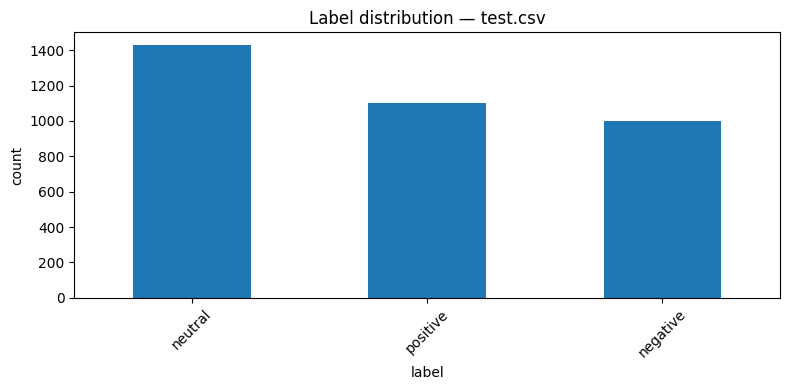


Does this dataset contain neutral? YES
  → string label 'neutral' present
What labels exist? [np.str_('negative'), np.str_('neutral'), np.str_('positive')]

### D. Text analysis
Using text column: text
Average word length: 9.367601246105918
Median word length: 8.0
Average char length: 49.745794392523365
Median char length: 45.0
Min / max words: 0 32
Min / max chars: 0 148

5 shortest texts (by word count):
  1. (0 words) nan
  2. (0 words) nan
  3. (0 words) nan
  4. (0 words) nan
  5. (0 words) nan

5 longest texts (by word count):
  1. (32 words) 'i was so bored i decided to iron all my baju sklh. thn i realized i hate doing tht. so all i did was iron a sleeve HAHAHA. im off to schl'
  2. (32 words) 'i got baby g wach its zi same as the 1 lady gaga wears in eh eh film clip but in pink!! I LOVE YOU KAY thanks a heap  i win olivia'
  3. (32 words) "my darling dd says 'my mum is my best friend'... and she told me to tell you all she said that in here too  so I did! love ya moo (jd too)

In [5]:
p = DATA_DIR / "test.csv"
if not p.exists():
    raise FileNotFoundError(f"Missing {p} — expected under data/datasets/sentiment-analysis/")
summary_rows.append(run_full_eda("test.csv", p))


### Dataset: `testdata.manual.2009.06.14.csv`

Sections A–G for this file.


## Dataset: testdata.manual.2009.06.14.csv

### A. Load dataset
Path: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis/data/datasets/sentiment-analysis/testdata.manual.2009.06.14.csv
Rows loaded: 516

### B. Basic info
shape: (516, 6)
column names: ['polarity', 'id', 'date', 'query', 'user', 'text']

head(5):
   polarity  id                          date    query      user                                                                                                                                          text
0         4   3  Mon May 11 03:17:40 UTC 2009  kindle2    tpryan                               @stellargirl I loooooooovvvvvveee my Kindle2. Not that the DX is cool, but the 2 is fantastic in its own right.
1         4   4  Mon May 11 03:18:03 UTC 2009  kindle2    vcu451                                                                                    Reading my kindle2...  Love it... Lee childs is good read.
2         4   5  Mon May 11 03:18:54 UTC 2009  

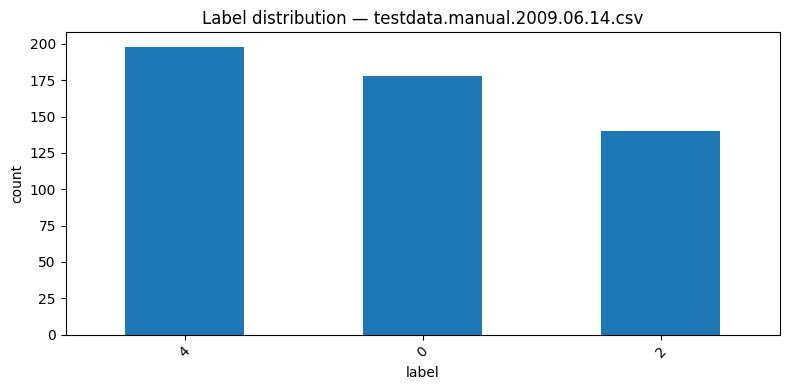


Does this dataset contain neutral? YES
  → numeric polarity 2 (Sentiment140 neutral)
What labels exist? [np.int64(0), np.int64(2), np.int64(4)]

### D. Text analysis
Using text column: text
Average word length: 13.472868217054264
Median word length: 12.0
Average char length: 79.79069767441861
Median char length: 75.0
Min / max words: 2 30
Min / max chars: 11 144

5 shortest texts (by word count):
  1. (2 words) 'Loves twitter'
  2. (2 words) 'eating sashimi'
  3. (2 words) 'eating cake'
  4. (2 words) 'Comcast sucks.'
  5. (2 words) 'Loves twitter'

5 longest texts (by word count):
  1. (30 words) 'I was talking to this guy last night and he was telling me that he is a die hard Spurs fan.  He also told me that he hates LeBron James.'
  2. (30 words) 'Give a man a fish, u feed him for the day. Teach him to fish, u feed him for life. Buy him GM, and u F**K him over for good.'
  3. (29 words) 'My dad was in NY for a day, we ate at MESA grill last night and met Bobby Flay. So much fun, ex

In [6]:
p = DATA_DIR / "testdata.manual.2009.06.14.csv"
if not p.exists():
    raise FileNotFoundError(f"Missing {p} — expected under data/datasets/sentiment-analysis/")
summary_rows.append(run_full_eda("testdata.manual.2009.06.14.csv", p))


### Dataset: `training.1600000.processed.noemoticon.csv`

Sections A–G for this file.


## Dataset: training.1600000.processed.noemoticon.csv

### A. Load dataset
Path: /Users/deepakmurali/Projects/Brand-Perception-and-Sentiment-Analysis/data/datasets/sentiment-analysis/training.1600000.processed.noemoticon.csv
Rows loaded: 1048572

### B. Basic info
shape: (1048572, 6)
column names: ['polarity', 'id', 'date', 'query', 'user', 'text']

head(5):
   polarity          id                          date     query           user                                                                                                             text
0         0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY  scotthamilton  is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
1         0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY       mattycus                        @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
2         0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUER

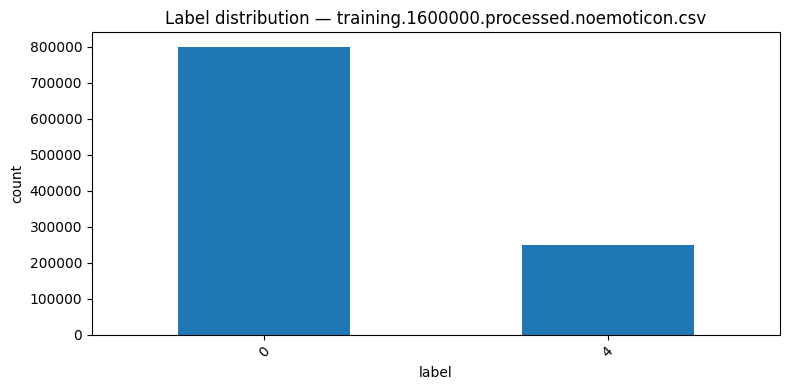


Does this dataset contain neutral? NO
  → numeric labels only (sample): [np.int64(0), np.int64(4)]
What labels exist? [np.int64(0), np.int64(4)]

### D. Text analysis
Using text column: text
Average word length: 13.404419534376276
Median word length: 12.0
Average char length: 74.29765338002541
Median char length: 70.0
Min / max words: 1 57
Min / max chars: 6 348

5 shortest texts (by word count):
  1. (1 words) 'Agh...snow!!! '
  2. (1 words) '@mandayyy '
  3. (1 words) '@mandayyy   '
  4. (1 words) 'homework.... '
  5. (1 words) '@danadearmond '

5 longest texts (by word count):
  1. (57 words) "I'm so boreeeeed. . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .I need internet. "
  2. (44 words) 'Is the saddest zornes ever thanks to the magic ( :  ( :  ( :  ( :  ( :  (  :  ( :  ( :  ( :  ( :  ( :  ( :  ( :  ( :  ( :  ( :  ( :   ...'
  3. (41 words) '@ajayrochester DO IT DO IT DO IT DO IT DO IT DO IT DO IT DO IT DO IT DO IT DO IT D

In [7]:
p = DATA_DIR / "training.1600000.processed.noemoticon.csv"
if not p.exists():
    raise FileNotFoundError(f"Missing {p} — expected under data/datasets/sentiment-analysis/")
summary_rows.append(run_full_eda("training.1600000.processed.noemoticon.csv", p))


## Summary table, CSV export, conclusions

Run after all dataset cells above.

In [8]:
print("\n" + "#" * 72)
print("## Final comparison")
print("#" * 72)

if not summary_rows:
    print("No datasets in summary_rows — run the per-dataset cells above.")
else:
    sum_df = pd.DataFrame(summary_rows)
    sum_df["recommended_usage"] = sum_df.apply(
        lambda r: recommend_usage(
            {
                "dataset": r["dataset"],
                "rows": r["rows"],
                "neutral_present": r["neutral_present"],
                "balanced": r["balanced"],
                "duplicates_pct": r["duplicates_pct"],
                "n_labels": r["n_labels"],
            }
        ),
        axis=1,
    )

    display_cols = [
        "dataset",
        "rows",
        "labels_present",
        "neutral_present",
        "balanced",
        "three_class",
        "avg_text_words",
        "avg_text_chars",
        "duplicates_pct",
        "recommended_usage",
    ]
    print("\n", sum_df[display_cols].to_string(index=False))

    sum_df.to_csv(OUT_CSV, index=False)
    print(f"\nSaved summary CSV: {OUT_CSV.resolve()}")

    print("\n" + "#" * 72)
    print("## Printed conclusions")
    print("#" * 72)

    neu_yes = sum_df[sum_df["neutral_present"] == "Y"]["dataset"].tolist()
    neu_no = sum_df[sum_df["neutral_present"] == "N"]["dataset"].tolist()
    print("\nDatasets with real neutral labels (numeric 2 or string 'neutral'):", neu_yes)
    print("Binary-only (no neutral in this sense):", neu_no)

    print("\nSuggested roles:")
    print(
        "  • Pretraining (scale): large Twitter/Sentiment140-style corpora with weak/binary labels."
    )
    print(
        "  • Fine-tuning: Kaggle train/test when you need string labels including neutral."
    )
    print(
        "  • Neutral source: any file flagged neutral_present=Y with enough neutral rows for 3-class."
    )
    print(
        "  • Combining: use train.csv (+ test.csv for eval) for 3-way neutral/pos/neg; use "
        "training.1600000... for extra binary supervision; use testdata.manual as a small benchmark "
        "with gold 0/2/4 if applicable."
    )

    print("\n3-class training readiness (from per-dataset checks):")
    for _, r in sum_df.iterrows():
        print(f"  • {r['dataset']}: three_class={r['three_class']} — {r['three_class_note']}")



########################################################################
## Final comparison
########################################################################

                                   dataset    rows              labels_present neutral_present balanced three_class  avg_text_words  avg_text_chars  duplicates_pct                                               recommended_usage
                                train.csv   27481 negative, neutral, positive               Y      YES         YES       12.902405       68.352462            0.00                 neutral source; fine-tuning; fine-tuning / eval
                                 test.csv    4815 negative, neutral, positive               Y      YES         YES        9.367601       49.745794           26.58                 neutral source; fine-tuning; fine-tuning / eval
           testdata.manual.2009.06.14.csv     516                     0, 2, 4               Y      YES         YES       13.472868       79.790698    